In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme()

In [86]:
df = pd.read_csv("/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [87]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [88]:
print(df.shape)

(395, 33)


In [89]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [90]:
print(df.describe())

              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
std      0.896659    0.9988

In [91]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [92]:
df.drop_duplicates(inplace=True)

In [93]:
df.fillna(method='ffill', inplace=True)

print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


/tmp/ipykernel_58/2113444329.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [94]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


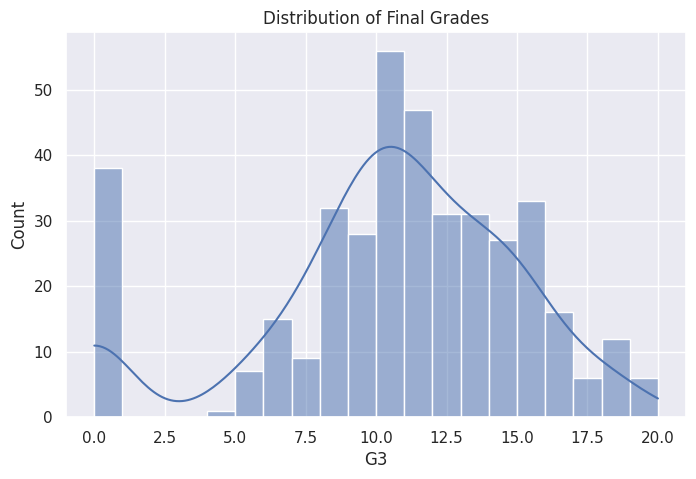

In [95]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title("Distribution of Final Grades")
plt.show()

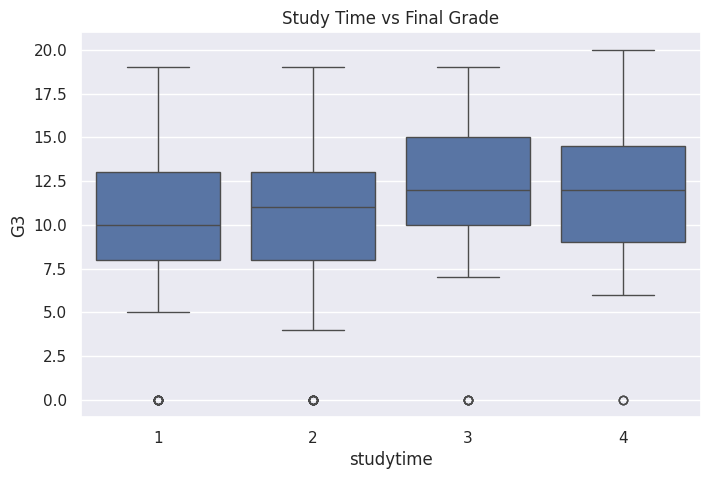

In [96]:
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=df)

plt.title("Study Time vs Final Grade")

plt.show()

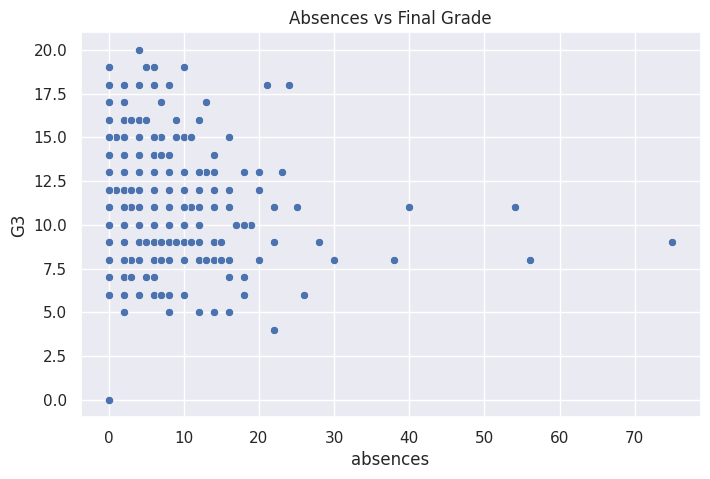

In [97]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='absences', y='G3', data=df)

plt.title("Absences vs Final Grade")

plt.show()

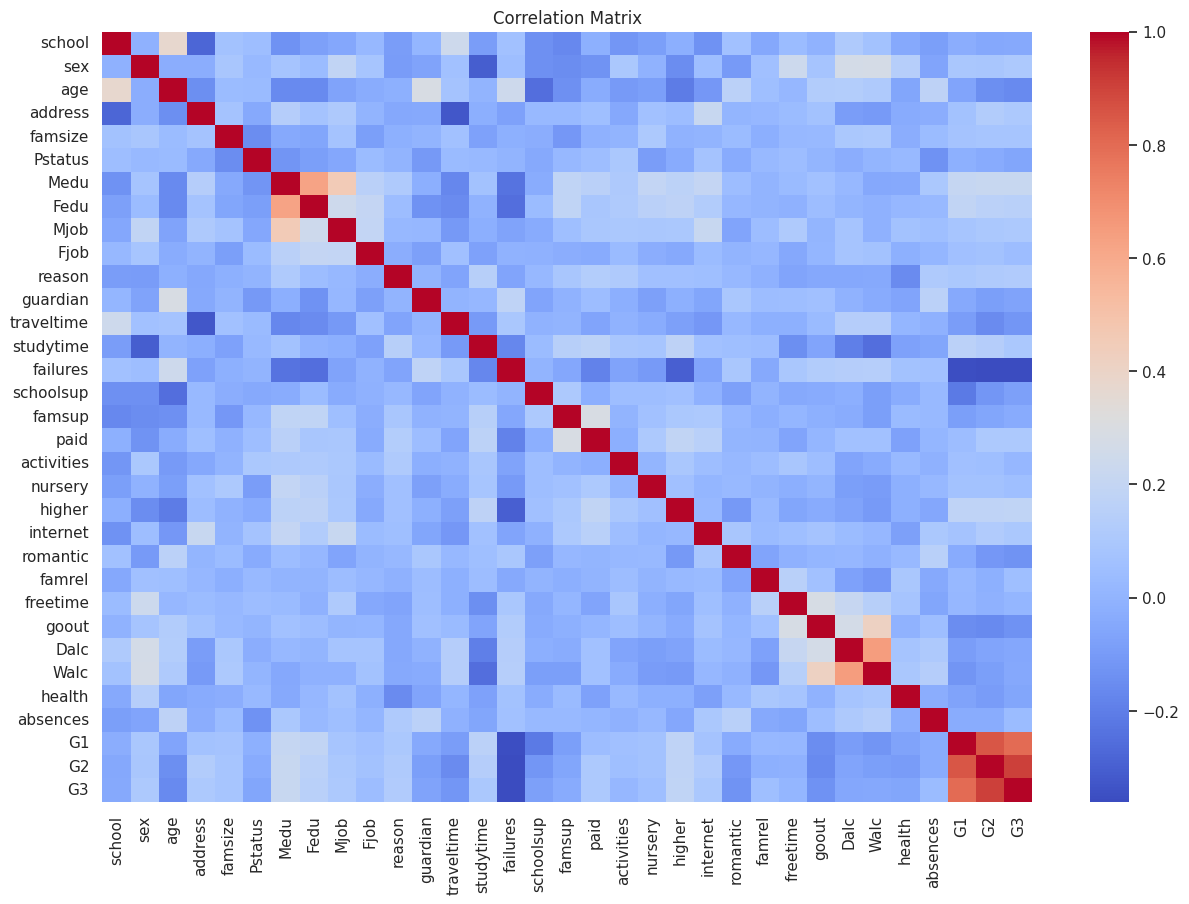

In [98]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [99]:
correlation = df.corr()['G3'].sort_values(ascending=False)

print(correlation.head(10))

G3         1.000000
G2         0.904868
G1         0.801468
Medu       0.217147
higher     0.182465
Fedu       0.152457
reason     0.121994
address    0.105756
sex        0.103456
Mjob       0.102082
Name: G3, dtype: float64


In [100]:
df['Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

X = df.drop(['G3', 'Result'], axis=1)
y = df['Result']

In [ ]:
print(correlation.head(10))

In [101]:
df['Result'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

X = df.drop(['G3', 'Result'], axis=1)
y = df['Result']

NameError: name 'y_pred_lr' is not defined

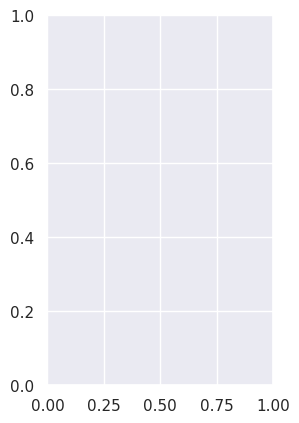

In [102]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='b')
plt.plot([0, 20], [0, 20], '--r')
plt.title('Linear Regression: Actual vs Predicted Grades')
plt.xlabel('Actual G3')
plt.ylabel('Predicted G3')

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9113924050632911


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.96      0.90      0.93        52

    accuracy                           0.91        79
   macro avg       0.90      0.91      0.90        79
weighted avg       0.92      0.91      0.91        79



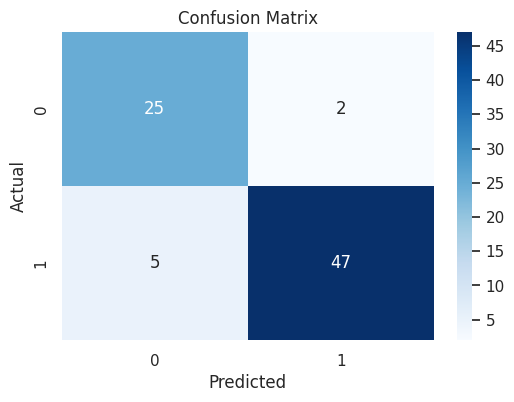

In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [106]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

     Feature  Importance
31        G2    0.362918
30        G1    0.206461
29  absences    0.040848
2        age    0.030221
14  failures    0.029940
25     goout    0.025687
7       Fedu    0.023092
8       Mjob    0.019468
24  freetime    0.019435
28    health    0.017991


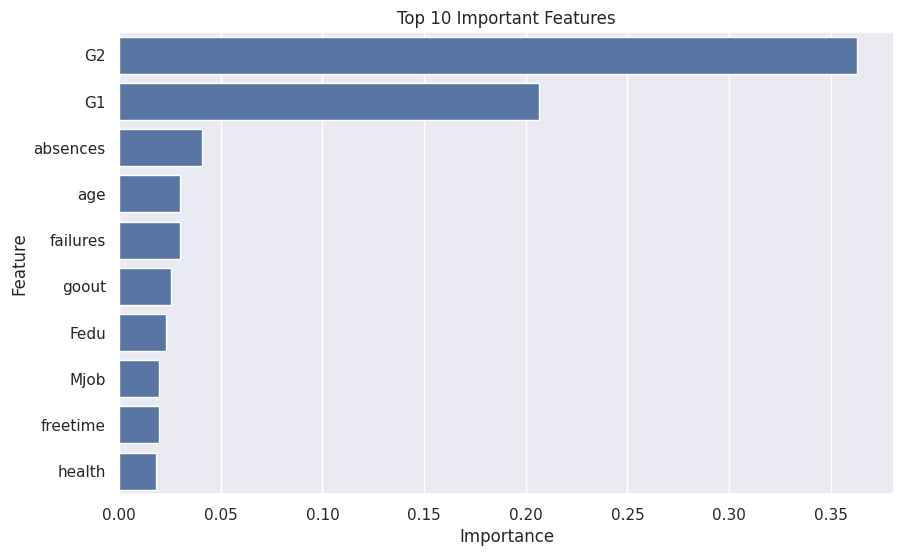

In [107]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [109]:
df = pd.read_csv('/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv', sep=',')
print(f"✅ Success! Dataset loaded natively from public repository.")
print(f"Dataset Dimensionality: {df.shape[0]} students with {df.shape[1]} attributes.\n")

✅ Success! Dataset loaded natively from public repository.
Dataset Dimensionality: 395 students with 33 attributes.



In [110]:
label_encoders = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='studytime', y='G3', data=df, palette='Set2')
plt.title("Impact of Weekly Study Time Allotted vs Final Grades (G3)")
plt.xlabel("Study Time Segment (1: <2 hrs, 2: 2-5 hrs, 3: 5-10 hrs, 4: >10 hrs)")
plt.ylabel("Final Exam Grade Points")
plt.show()

In [111]:
X = df.drop(columns=['G3', 'G2', 'G1'])
y = df['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=10, n_estimators=150, random_state=42)

In [113]:
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Predictive Assessment Report ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} grade points")
print(f"R-squared Variance Explained (R²): {r2:.4f}\n")

--- Predictive Assessment Report ---
Mean Absolute Error (MAE): 3.00 grade points
R-squared Variance Explained (R²): 0.3241



/tmp/ipykernel_58/1890257432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:8]], y=X.columns[indices[:8]], palette='viridis')


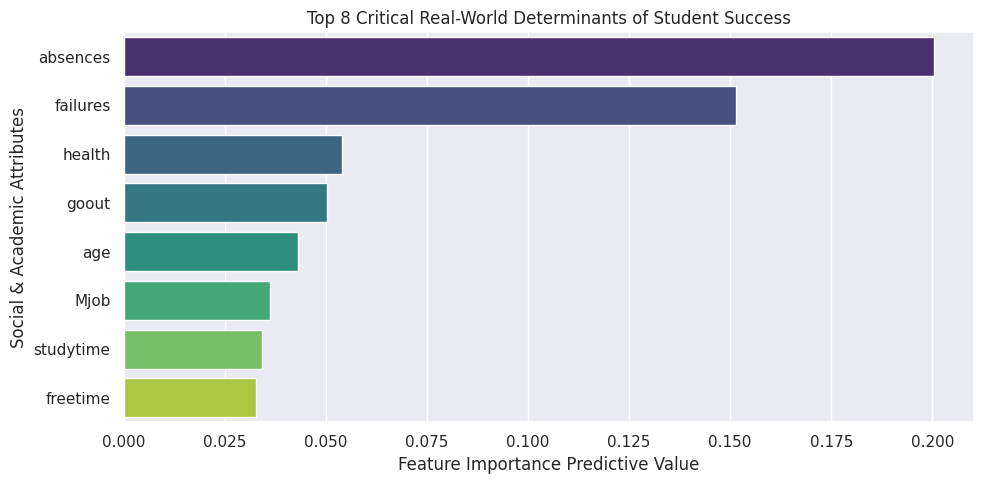

In [114]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices[:8]], y=X.columns[indices[:8]], palette='viridis')
plt.title("Top 8 Critical Real-World Determinants of Student Success")
plt.xlabel("Feature Importance Predictive Value")
plt.ylabel("Social & Academic Attributes")
plt.tight_layout()
plt.show()